# Stokes Vectors

**Scott Prahl**

*Feb 2026*

In [1]:
%config InlineBackend.figure_format = 'retina'

import sys
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["animation.html"] = "jshtml"

if sys.platform == "emscripten":
    import micropip

    await micropip.install("pypolar")

from pypolar import jones
from pypolar import mueller
from pypolar import visualization as vis

## Introduction

The basics of Stokes vectors and their implementation in the `pypolar` modules.  This notebooks shows how to create Stokes vectors, convert to and from Jones vectors, visualize, and interpret them.

## Creation

The Stokes vectors are numpy arrays of `[I,Q,U,V]`.  There are a bunch of routines that support linear, circular, and elliptical polarization.

### Linear Polarization

In [ ]:
light = mueller.stokes_horizontal()
print("Stokes vector for horizontally-polarized light")
print(np.round(light,4))

light = mueller.stokes_linear(0)
print("Stokes vector for 0° linearly polarized light")
print(np.round(light,4))

light = mueller.stokes_vertical()
print("Stokes vector for vertically-polarized light")
print(np.round(light,4))

light = mueller.stokes_linear(np.pi / 2)
print("Stokes vector for 90° linearly polarized light")
print(np.round(light,4))

light = mueller.stokes_linear(np.radians(45))
print("Stokes vector for 45° linearly polarized light")
print(np.round(light,4))

light = mueller.stokes_linear(np.radians(-45))
print("Stokes vector for -45° linearly polarized light")
print(np.round(light,4))

light = mueller.stokes_linear(np.radians(30))
print("Stokes vector for 30° linearly polarized light")
print(np.round(light,4))

light = mueller.stokes_linear(np.radians(-60))
print("Stokes vector for -60° linearly polarized light")
print(np.round(light,4))

### Circular Polarization

In [2]:
light = mueller.stokes_right_circular()
print("Stokes vector for right circularly polarized light")
print(np.round(light,4))

light = mueller.stokes_left_circular()
print("Stokes vector for left circularly polarized light")
print(np.round(light,4))

Stokes vector for horizontally-polarized light
[1 1 0 0]
Stokes vector for 0° linearly polarized light
[1. 1. 0. 0.]
Stokes vector for vertically-polarized light
[ 1 -1  0  0]
Stokes vector for 90° linearly polarized light
[ 1. -1.  0.  0.]
Stokes vector for 45° linearly polarized light
[1. 0. 1. 0.]
Stokes vector for -45° linearly polarized light
[ 1.  0. -1.  0.]
Stokes vector for 30° linearly polarized light
[1.    0.5   0.866 0.   ]
Stokes vector for -60° linearly polarized light
[ 1.    -0.5   -0.866  0.   ]
Stokes vector for right circularly polarized light
[1 0 0 1]
Stokes vector for left circularly polarized light
[ 1  0  0 -1]


### Elliptical polarization

Examples from Appendix A in Kliger.

In [3]:
azimuth = 0
ellipticity = 0.5
light = mueller.stokes_elliptical(1, azimuth, ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(np.round(light,4))

azimuth = 0
ellipticity = -0.5
light = mueller.stokes_elliptical(1, azimuth, ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(np.round(light,4))

azimuth = 90
ellipticity = 0.5
light = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(np.round(light,4))

azimuth = 90
ellipticity = -0.5
light = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(np.round(light,4))

azimuth = 45
ellipticity = 0.414
light = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(np.round(light,4))

azimuth = 45
ellipticity = -0.414
light = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(np.round(light,4))

azimuth = 25.38
ellipticity = 0.342
light = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(np.round(light,4))

azimuth = -64.62
ellipticity = -0.342
light = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(np.round(light,4))


Elliptically polarized (azimuth=0.00°, ellipticity=0.500)
[1.  0.6 0.  0.8]
Elliptically polarized (azimuth=0.00°, ellipticity=-0.500)
[ 1.   0.6  0.  -0.8]
Elliptically polarized (azimuth=90.00°, ellipticity=0.500)
[ 1.  -0.6  0.   0.8]
Elliptically polarized (azimuth=90.00°, ellipticity=-0.500)
[ 1.  -0.6  0.  -0.8]
Elliptically polarized (azimuth=45.00°, ellipticity=0.414)
[1.     0.     0.7074 0.7068]
Elliptically polarized (azimuth=45.00°, ellipticity=-0.414)
[ 1.      0.      0.7074 -0.7068]
Elliptically polarized (azimuth=25.38°, ellipticity=0.342)
[1.     0.5001 0.6123 0.6124]
Elliptically polarized (azimuth=-64.62°, ellipticity=-0.342)
[ 1.     -0.5001 -0.6123 -0.6124]


## Stokes to Jones Conversion


In [4]:
S = mueller.stokes_horizontal()
print("Stokes vector for horizontally-polarized light")
print(np.round(S,4))
J = mueller.stokes_to_jones(S)
print("Jones conversion")
print(np.round(J,4))
print("Actual Jones vector")
print(np.round(jones.field_horizontal(),4))

Stokes vector for horizontally-polarized light
[1 1 0 0]
Jones conversion
[1.+0.j 0.+0.j]
Actual Jones vector
[1 0]


In [5]:
S = mueller.stokes_vertical()
print("Stokes vector for vertically-polarized light")
print(np.round(S,4))
J = mueller.stokes_to_jones(S)
print("Jones conversion")
print(np.round(J,4))
print("Actual Jones vector")
print(np.round(jones.field_vertical(),4))

Stokes vector for vertically-polarized light
[ 1 -1  0  0]
Jones conversion
[0. 1.]
Actual Jones vector
[0 1]


In [6]:
angle = 30 * np.pi / 180
S = mueller.stokes_linear(angle)
print("Stokes vector for linearly-polarized light at %.1f°" % (angle * 180 / np.pi))
print(np.round(S,4))
J = mueller.stokes_to_jones(S)
print("Jones conversion")
print(np.round(J,4))
print("Actual Jones vector")
print(np.round(jones.field_linear(angle),4))

Stokes vector for linearly-polarized light at 30.0°
[1.    0.5   0.866 0.   ]
Jones conversion
[0.866+0.j 0.5  +0.j]
Actual Jones vector
[0.866 0.5  ]


In [7]:
S = mueller.stokes_right_circular()
print("Stokes vector for right-circular-polarized light")
print(np.round(S,4))
J = mueller.stokes_to_jones(S)
print("Jones conversion")
print(np.round(J,4))
print("Actual Jones vector")
print(np.round(jones.field_right_circular(),4))

Stokes vector for right-circular-polarized light
[1 0 0 1]
Jones conversion
[0.7071+0.j     0.    +0.7071j]
Actual Jones vector
[0.7071+0.j     0.    +0.7071j]


In [8]:
S = mueller.stokes_left_circular()
print("Stokes vector for left-circular-polarized light")
print(np.round(S,4))
J = mueller.stokes_to_jones(S)
print("Jones conversion")
print(np.round(J,4))
print("Actual Jones vector")
print(np.round(jones.field_left_circular(),4))

Stokes vector for left-circular-polarized light
[ 1  0  0 -1]
Jones conversion
[0.7071+0.j     0.    -0.7071j]
Actual Jones vector
[0.7071+0.j     0.    -0.7071j]


## Visualization

These only show the polarized component of the Stokes vector.

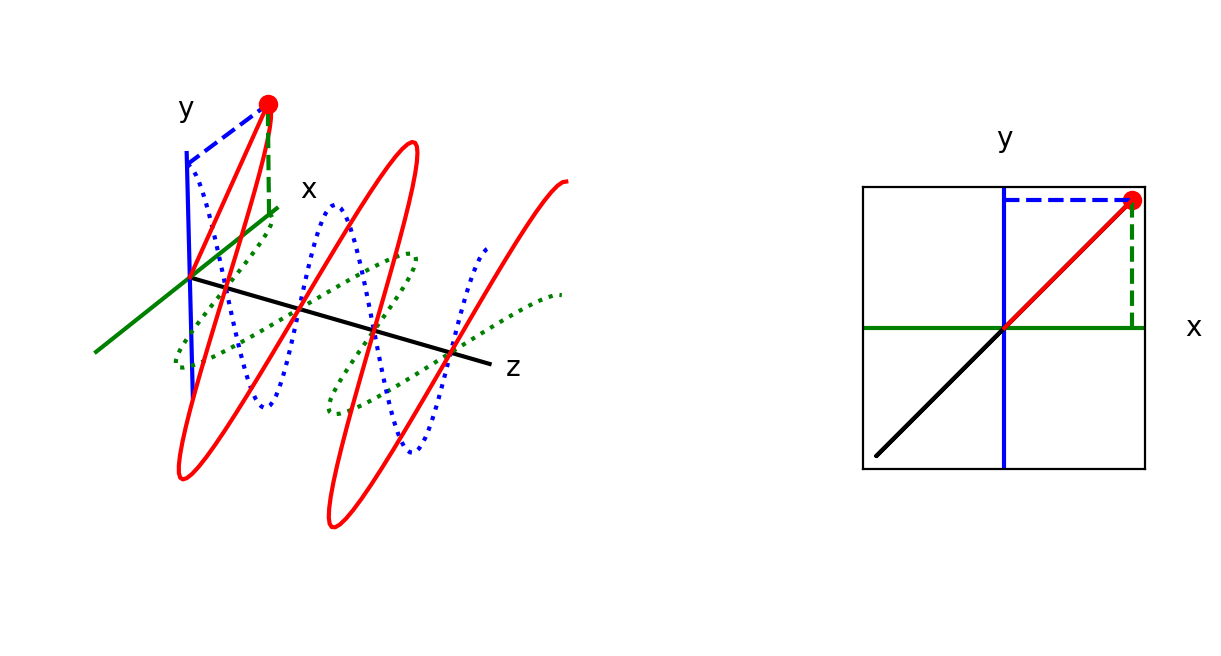

In [9]:
theta = np.radians(45)
v = mueller.stokes_linear(theta)
vis.draw_stokes_field(v)
plt.show()

In [11]:
azimuth = -64.62
ellipticity = -0.342
S = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
ani=vis.draw_stokes_animated(S)
ani

## Field Interpretation

In [12]:
v = mueller.stokes_horizontal()
s=mueller.interpret(v)
print(s)

I = 1.000
Q = 1.000
U = 0.000
V = 0.000
Degree of polarization = 1.000
Fully polarized light
Linear polarization at 0.0 degrees CCW from x-axis


In [13]:
v = mueller.stokes_vertical()
s=mueller.interpret(v)
print(s)

I = 1.000
Q = -1.000
U = 0.000
V = 0.000
Degree of polarization = 1.000
Fully polarized light
Linear polarization at 90.0 degrees CCW from x-axis


In [14]:
theta = np.radians(15)
v = mueller.stokes_linear(theta)
s = mueller.interpret(v)
print(s)

I = 1.000
Q = 0.866
U = 0.500
V = 0.000
Degree of polarization = 1.000
Fully polarized light
Linear polarization at 15.0 degrees CCW from x-axis


In [15]:
v = np.array([3 * np.exp(-1j * np.pi), 3 * np.exp(-1j * np.pi / 3)])
s=mueller.interpret(v)
print(s)

Malformed input: input has non-zero imaginary parts; Mueller/Stokes quantities must be real


In [16]:
v = np.array([1,2])
s=mueller.interpret(v)
print(s)

Malformed input: expected a Stokes vector with shape (4,) or a Mueller matrix with shape (4, 4), got shape (2,)
